Generation 1 : Best Affinity = 0.1018
Generation 2 : Best Affinity = 0.1386
Generation 3 : Best Affinity = 0.167
Generation 4 : Best Affinity = 0.1672
Generation 5 : Best Affinity = 0.179
Generation 6 : Best Affinity = 0.1957
Generation 7 : Best Affinity = 0.1983
Generation 8 : Best Affinity = 0.1997
Generation 9 : Best Affinity = 0.1997
Generation 10 : Best Affinity = 0.2
Generation 11 : Best Affinity = 0.2
Generation 12 : Best Affinity = 0.2
Generation 13 : Best Affinity = 0.2006
Generation 14 : Best Affinity = 0.2006
Generation 15 : Best Affinity = 0.2006
Generation 16 : Best Affinity = 0.2006
Generation 17 : Best Affinity = 0.2006
Generation 18 : Best Affinity = 0.2006
Generation 19 : Best Affinity = 0.2006
Generation 20 : Best Affinity = 0.2006
Generation 21 : Best Affinity = 0.2006
Generation 22 : Best Affinity = 0.2006
Generation 23 : Best Affinity = 0.2006
Generation 24 : Best Affinity = 0.2006
Generation 25 : Best Affinity = 0.2006
Generation 26 : Best Affinity = 0.2006
Genera

ERROR: Invalid requirement: 'numpy,matplotlib': Expected end or semicolon (after name and no valid version specifier)
    numpy,matplotlib
         ^


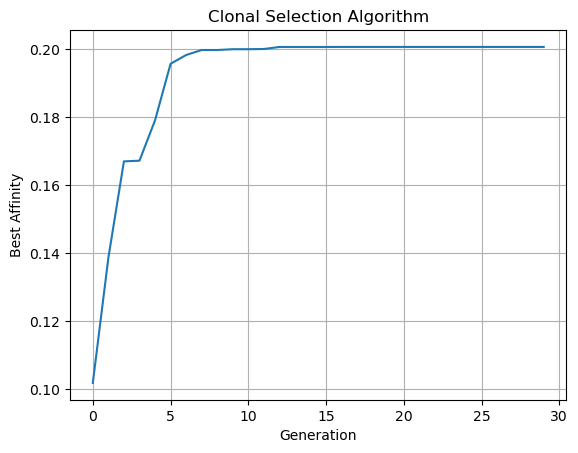

In [2]:
!pip install numpy,

# ---------------------------------------------------------
# CLONAL SELECTION ALGORITHM
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Fitness Function (Rastrigin Function)
# Lower value = better solution
# ---------------------------------------------------------

def rastrigin(x):

    A = 10

    return A * len(x) + sum(
        (xi ** 2 - A * np.cos(2 * np.pi * xi))
        for xi in x
    )



# ---------------------------------------------------------
# Generate Initial Population
# ---------------------------------------------------------

def create_population(size, dimension, bounds):

    population = []

    for i in range(size):

        individual = np.random.uniform(
            bounds[0],
            bounds[1],
            dimension
        )

        population.append(
            individual
        )

    return population



# ---------------------------------------------------------
# Affinity Calculation
# Higher affinity = better
# ---------------------------------------------------------

def calculate_affinity(population):

    affinity = []

    for individual in population:

        fit = rastrigin(
            individual
        )

        affinity.append(
            1 / (1 + fit)
        )

    return affinity



# ---------------------------------------------------------
# Clone and Mutate
# ---------------------------------------------------------

def clone_and_mutate(selected,
                     clone_factor,
                     mutation_rate,
                     bounds):

    clones = []


    for individual in selected:


        for i in range(
            clone_factor
        ):


            clone = individual.copy()


            mutation = np.random.uniform(
                -mutation_rate,
                mutation_rate,
                len(clone)
            )


            clone = clone + mutation


            clone = np.clip(
                clone,
                bounds[0],
                bounds[1]
            )


            clones.append(
                clone
            )


    return clones



# ---------------------------------------------------------
# Parameters
# ---------------------------------------------------------

POPULATION_SIZE = 20
GENERATIONS = 30
CLONE_FACTOR = 5
MUTATION_RATE = 0.1

DIMENSION = 2

BOUNDS = (-5.12, 5.12)



# ---------------------------------------------------------
# Main Algorithm
# ---------------------------------------------------------

population = create_population(
    POPULATION_SIZE,
    DIMENSION,
    BOUNDS
)


best_affinity_history = []


for generation in range(
    GENERATIONS
):


    affinity = calculate_affinity(
        population
    )


    # Select best half

    indices = np.argsort(
        affinity
    )[-POPULATION_SIZE // 2:]


    selected = [

        population[i]

        for i in indices
    ]


    # Clone + mutate

    clones = clone_and_mutate(
        selected,
        CLONE_FACTOR,
        MUTATION_RATE,
        BOUNDS
    )


    # Combine old + clones

    population = (
        population + clones
    )


    # Recalculate

    affinity = calculate_affinity(
        population
    )


    # Keep best individuals

    indices = np.argsort(
        affinity
    )[-POPULATION_SIZE:]


    population = [

        population[i]

        for i in indices
    ]


    best_affinity = max(
        affinity
    )


    best_affinity_history.append(
        best_affinity
    )


    print(
        "Generation",
        generation + 1,
        ": Best Affinity =",
        round(best_affinity, 4)
    )



# ---------------------------------------------------------
# Final Best Solution
# ---------------------------------------------------------

final_affinity = calculate_affinity(
    population
)


best_index = np.argmax(
    final_affinity
)


best_solution = population[
    best_index
]


print("\nBest Solution :",
      best_solution)

print("Best Affinity :",
      round(
          final_affinity[
              best_index
          ],
          4
      ))



# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

plt.plot(
    best_affinity_history
)

plt.title(
    "Clonal Selection Algorithm"
)

plt.xlabel(
    "Generation"
)

plt.ylabel(
    "Best Affinity"
)

plt.grid()

plt.show()